In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import numpy as np

# Dataset Loading

In [44]:
df = pd.read_csv('employee_shortlisting.csv')

In [45]:
df.head()

,Interview_Score,Skills_Matched,Shortlisted
0,8.730597,3.245203,Yes
1,6.070919,2.105576,No
2,8.254656,2.682729,Yes
3,6.136732,2.777711,No
4,8.785921,3.233440,Yes


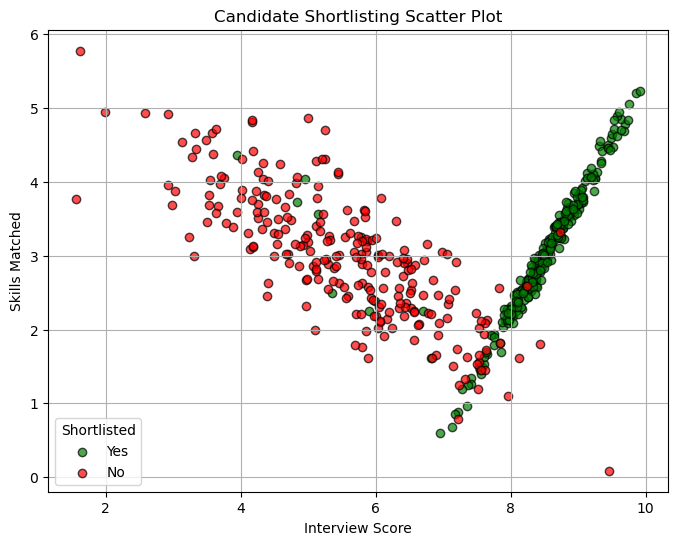

In [46]:
df = pd.read_csv('employee_shortlisting.csv')

# Scatter plot
plt.figure(figsize=(8, 6))
colors = {'Yes': 'green', 'No': 'red'}

for label in df['Shortlisted'].unique():
    subset = df[df['Shortlisted'] == label]
    plt.scatter(subset['Interview_Score'], subset['Skills_Matched'],
                c=colors[label], label=label, alpha=0.7, edgecolors='k')

plt.title("Candidate Shortlisting Scatter Plot")
plt.xlabel("Interview Score")
plt.ylabel("Skills Matched")
plt.legend(title="Shortlisted")
plt.grid(True)
plt.show()

# Model Building

In [47]:
df = pd.read_csv('employee_shortlisting.csv')

# Features and target
df['Shortlisted'] = df['Shortlisted'].map({'Yes': 1, 'No': 0})
X = df[["Interview_Score", "Skills_Matched"]].values.astype(float)
y = df["Shortlisted"].values.astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define classifiers
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(max_depth = 5, min_samples_split = 20, random_state=42),
    "Random Forest": RandomForestClassifier(max_depth = 5,random_state=42),
    "SVC": SVC(kernel='rbf')
}


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, 'Accuracy Score', round(accuracy_score(y_test, y_pred),2))

Logistic Regression Accuracy Score 0.9
KNN Accuracy Score 0.95
Decision Tree Accuracy Score 0.94
Random Forest Accuracy Score 0.93
SVC Accuracy Score 0.92


Logistic Regression Accuracy Score 0.9
KNN Accuracy Score 0.95
Decision Tree Accuracy Score 0.94
Random Forest Accuracy Score 0.93
SVC Accuracy Score 0.92


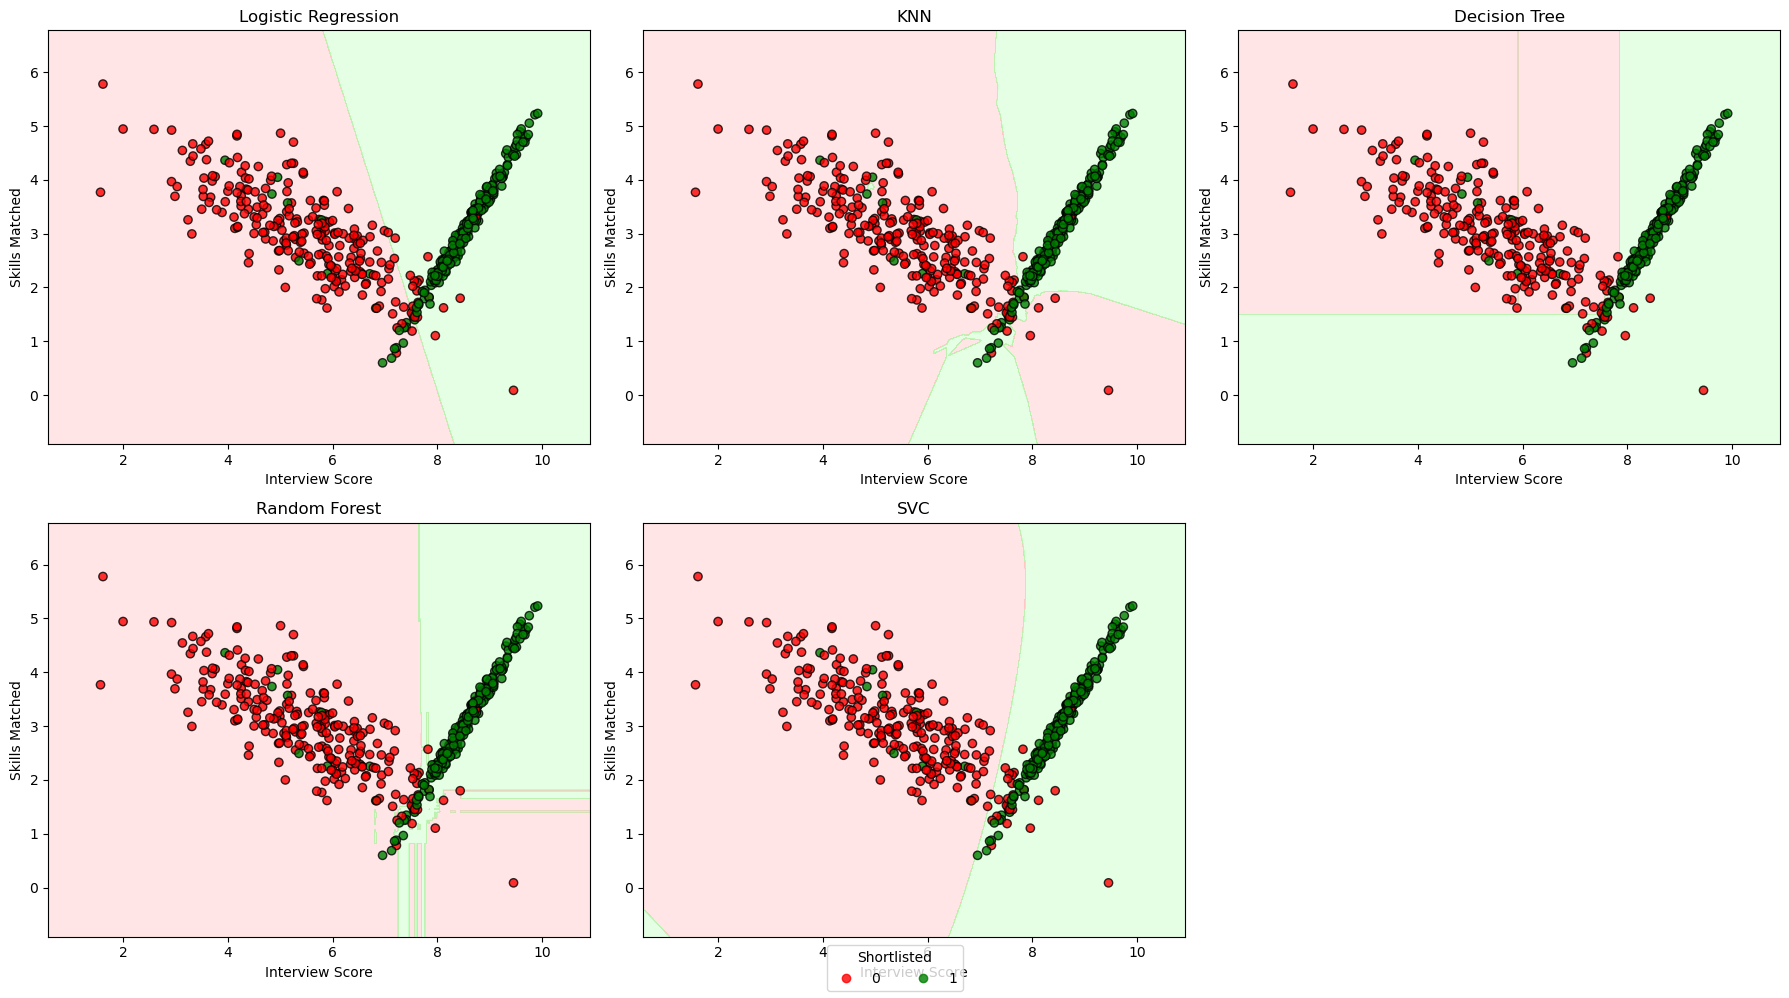

In [48]:

# Create mesh grid for plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Plot decision boundaries
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ['red', 'green']

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, 'Accuracy Score', round(accuracy_score(y_test, y_pred),2))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    scatter = axes[idx].scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(cmap_bold), edgecolor='k', alpha=0.8)
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Interview Score")
    axes[idx].set_ylabel("Skills Matched")

# Hide unused subplot
fig.delaxes(axes[-1])

# Add legend
fig.legend(*scatter.legend_elements(), loc='lower center', ncol=2, title="Shortlisted")
plt.tight_layout()
plt.show()

In [49]:
# Regression models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

In [50]:
df = pd.read_csv('marketing_spend.csv')
df.head()

,Date,Marketing_Spend_1000s,Employee_Count,Product_Rating,Customer_Acquisition_Cost,Quarterly_Revenue,Annual_Revenue,Customer_Lifetime_Value
0,2024-01-01,43.708611,18.250200,7.283455,1910.442649,265.106375,273.074702,354.029924
1,2024-01-02,95.564288,22.329398,5.824867,9132.533060,687.783503,567.896906,1012.873825
2,2024-01-03,75.879455,43.301150,3.785749,5757.691655,518.959402,520.257186,800.570271
3,2024-01-04,63.879264,19.261490,8.324155,4080.560315,378.920094,389.676220,577.055925
4,2024-01-05,24.041678,12.627174,7.162581,578.002264,169.671985,178.742889,193.317841


In [75]:

# Select features and target variable
X = df[['Marketing_Spend_1000s', 'Employee_Count','Product_Rating']]  # Independent variables
y = df['Quarterly_Revenue']  # Dependent variable

# train-test split 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state=42)

# Define classifiers
models = {
    "KNN": KNeighborsRegressor(n_neighbors=10),
    "Decision Tree": DecisionTreeRegressor(max_depth = 3,random_state=42),
    "Random Forest": RandomForestRegressor(max_depth = 4,random_state=42),
    "SVR": SVR(kernel='linear')
}


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, 'Accuracy Score', round(r2_score(y_test, y_pred),2))

KNN Accuracy Score 0.93
Decision Tree Accuracy Score 0.86
Random Forest Accuracy Score 0.91
SVR Accuracy Score 0.94
